<a href="https://colab.research.google.com/github/Sakshi-zz/Machine_Failure_prediction_model/blob/main/Sakshi_Rana_Machine_Failure_Prediction_Model_Data_Science_July_Batch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **# Machine Failure Prediction Project**

---



## **Dataset Overview**
This dataset contains sensor data collected from various machines , with the aim of predicting machine failures in advance. It include a variety of sensor reading as well as the recorded machine failures.


## **Columns Description**

*   Footfall: The number of people or objects passing by the machine.
*   TempMode: The temperature mode or setting of the machine.
*   AQ: Air quality index near the machine.
*   USS: Ulterasonic sensor data, indicating proximity measurements.
*   CS: Current sensor reading, indicating the electrical current usage of
    machine
*   VOC: Volatile organic compounds level detected near the machine.
*   RP: Rotational position or RPM (revolutions per minute) of the machine.
*   IP: Imput pressure to the machine.
*   Temperature: The operating temperature of the machine.
*   Fail: Binary indicator of machine failure (1 for failure, 0 for no failure).


---



## Import the necessary liberaries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

## Load dataset

In [20]:
sensor_data = pd.read_csv('/content/Kaggle_sensor_data.csv')
sensor_data

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0
...,...,...,...,...,...,...,...,...,...,...
939,0,7,7,1,6,4,73,6,24,1
940,0,7,5,2,6,6,50,6,24,1
941,0,3,6,2,7,5,43,6,24,1
942,0,6,6,2,5,6,46,7,24,1


## Exploratory Data Analysis (EDA)

In [ ]:
print(sensor_data.isnull().sum())

footfall       0
tempMode       0
AQ             0
USS            0
CS             0
VOC            0
RP             0
IP             0
Temperature    0
fail           0
dtype: int64


In [ ]:
sensor_data.shape

(944, 10)

In [ ]:
sensor_data.columns

Index(['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP',
       'Temperature', 'fail'],
      dtype='object')

In [ ]:
sensor_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   footfall     944 non-null    int64
 1   tempMode     944 non-null    int64
 2   AQ           944 non-null    int64
 3   USS          944 non-null    int64
 4   CS           944 non-null    int64
 5   VOC          944 non-null    int64
 6   RP           944 non-null    int64
 7   IP           944 non-null    int64
 8   Temperature  944 non-null    int64
 9   fail         944 non-null    int64
dtypes: int64(10)
memory usage: 73.9 KB


In [ ]:
sensor_data.describe(include = 'all')

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
count,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000
mean,306.381356,3.727754,4.325212,2.939619,5.394068,2.842161,47.043432,4.565678,16.331568,0.416314
std,1082.606745,2.677235,1.438436,1.383725,1.269349,2.273337,16.423130,1.599287,5.974781,0.493208
min,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,19.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,3.000000,2.000000,5.000000,1.000000,34.000000,3.000000,14.000000,0.000000
50%,22.000000,3.000000,4.000000,3.000000,6.000000,2.000000,44.000000,4.000000,17.000000,0.000000
75%,110.000000,7.000000,6.000000,4.000000,6.000000,5.000000,58.000000,6.000000,21.000000,1.000000
max,7300.000000,7.000000,7.000000,7.000000,7.000000,6.000000,91.000000,7.000000,24.000000,1.000000


In [ ]:
sensor_data.head()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


In [ ]:
sensor_data.tail()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
939,0,7,7,1,6,4,73,6,24,1
940,0,7,5,2,6,6,50,6,24,1
941,0,3,6,2,7,5,43,6,24,1
942,0,6,6,2,5,6,46,7,24,1
943,18,7,4,2,6,3,61,7,24,1


## Data Visualization

In [ ]:
correlation = sensor_data.corr()
print(correlation["fail"])

footfall      -0.073066
tempMode      -0.014462
AQ             0.583238
USS           -0.466574
CS             0.018855
VOC            0.797329
RP             0.053668
IP             0.085624
Temperature    0.190257
fail           1.000000
Name: fail, dtype: float64


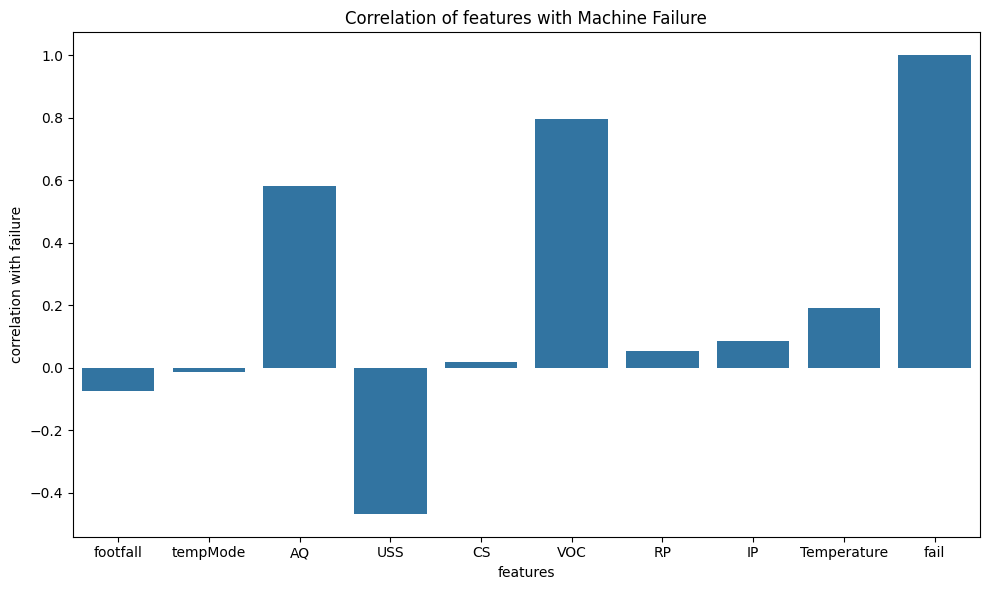

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=correlation['fail'].index , y=correlation['fail'].values)
plt.xlabel("features")
plt.ylabel("correlation with failure")
plt.title("Correlation of features with Machine Failure")
plt.tight_layout()
plt.show()

## Train Test Data Splitting

In [10]:
feature_cols = ['footfall','tempMode','AQ','USS','CS','VOC','RP','IP','Temperature']
X = sensor_data[feature_cols]
y = sensor_data['fail']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (755, 9)
Test shape: (189, 9)


## Model Training

In [12]:
models = {
    'Majority Baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=5),
}

results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    y_proba = m.predict_proba(X_test)[:, 1] if hasattr(m, 'predict_proba') else [0]*len(y_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba) if name != 'Majority Baseline' else 0.5,
    })

results_df = pd.DataFrame(results).round(4)
print(results_df)

                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0    Majority Baseline    0.5820     0.0000  0.0000  0.0000   0.5000
1  Logistic Regression    0.9365     0.9351  0.9114  0.9231   0.9780
2        Random Forest    0.9312     0.9231  0.9114  0.9172   0.9753


In [13]:
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
print(cm)
print(classification_report(y_test, y_pred_best))

[[104   6]
 [  7  72]]
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       110
           1       0.92      0.91      0.92        79

    accuracy                           0.93       189
   macro avg       0.93      0.93      0.93       189
weighted avg       0.93      0.93      0.93       189



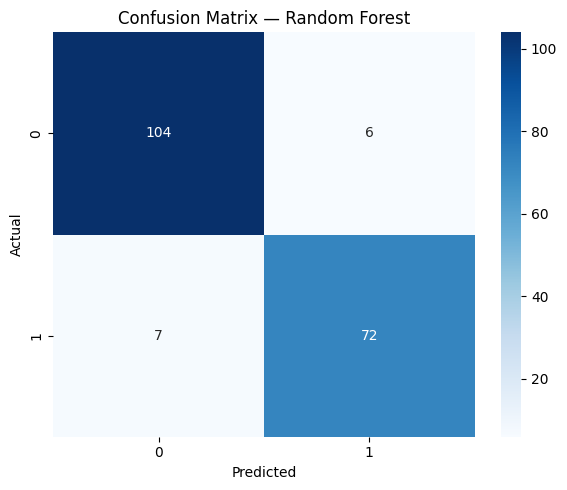

In [14]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# feature predict data model

new_data = pd.DataFrame({
    'footfall': [100],
    'tempMode': [3],
    'AQ': [4],
    'USS': [3],
    'CS': [6],
    'VOC': [2],
    'RP': [45],
    'IP': [4],
    'Temperature': [17],
})

new_scaled = scaler.transform(new_data)
print("Prediction:", best_model.predict(new_scaled))
print("Probability of failure:", best_model.predict_proba(new_scaled)[0, 1])

Prediction: [0]
Probability of failure: 0.03


In [16]:
#Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred_best)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy: 0.9312 (93.12%)


In [17]:
# cross-validation
for name, m in models.items():
    if name == 'Majority Baseline':
        continue
    scores = cross_val_score(m, X_train, y_train, cv=5, scoring='f1')
    print(f"{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression: F1 = 0.8788 ± 0.0247
Random Forest: F1 = 0.8714 ± 0.0236


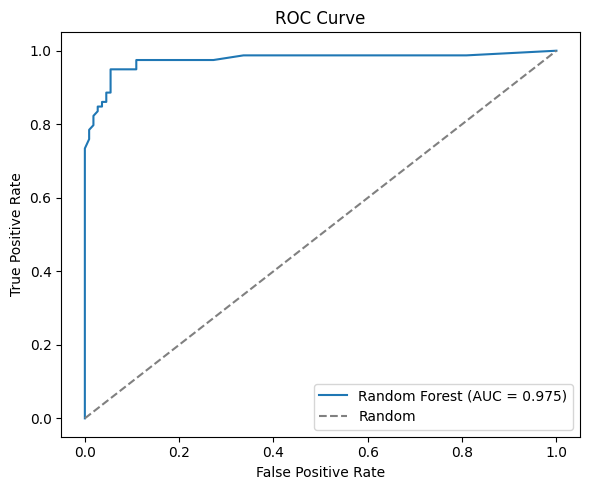

In [18]:
#ROC curve
y_proba_best = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc = roc_auc_score(y_test, y_proba_best)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], '--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

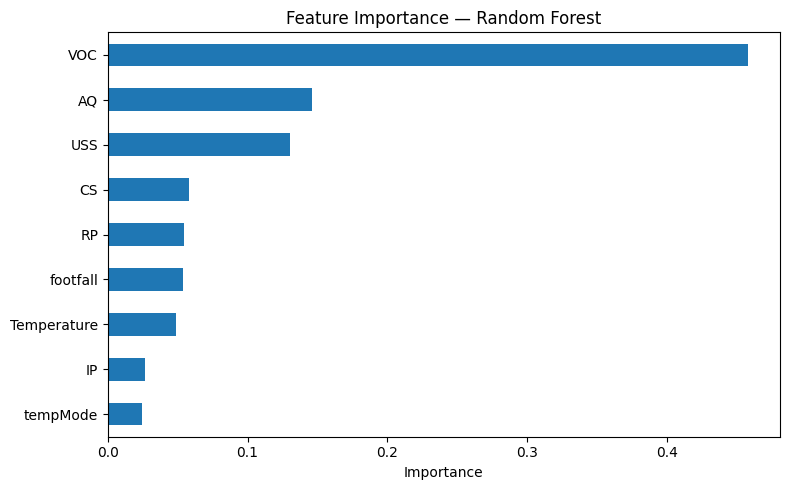

In [19]:
importances = pd.Series(
    best_model.feature_importances_, index=feature_cols
).sort_values()

plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()